In [14]:
import numba
from numba import cuda
from matplotlib import pyplot
import numpy as np
import time

img = pyplot.imread("image.jpg")

height = len(img)
width = len(img[0])
pixelCount = height*width
print(height,"*",width," = ",pixelCount," pixels")
#print(img)
#pyplot.imshow(img)
#pyplot.show()

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


9000 * 12000  =  108000000  pixels


In [15]:
matrix_list = [[0, 0, 1, 2, 1, 0, 0],
    [0, 3, 13, 22, 13, 3, 0],
    [1, 13, 59, 97, 59, 13, 1],
    [2, 22, 97, 159, 97, 22, 2],
    [1, 13, 59, 97, 59, 13, 1],
    [0, 3, 13, 22, 13, 3, 0],
    [0, 0, 1, 2, 1, 0, 0]]

matrix = np.array(matrix_list, dtype=np.int32)
matrixSide = matrix.shape[0]
matrixSum = int(np.sum(matrix))
offset = matrixSide // 2

In [16]:
from matplotlib.image import imsave
@cuda.jit
def GPU_Gaussian_Blur_Convolution(src, dst, matrix, matrixSum, offset):
  x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

  height = src.shape[0]
  width = src.shape[1]
  matrixSide = matrix.shape[0]

  if y < height and x < width:
    #Adressing the elephant in the room (edges), they will remain unchanged
    if y < offset or y >= (height - offset) or x < offset or x >= (width - offset):
      dst[y,x,0] = src[y,x,0]
      dst[y,x,1] = src[y,x,1]
      dst[y,x,2] = src[y,x,2]
    else:
      blur_r=blur_g=blur_b=0

      #Applying the matrix
      for ky in range(matrixSide):
        for kx in range(matrixSide):
          blur_r+=src[y+ky-offset,x+kx-offset,0]*matrix[ky,kx]
          blur_g+=src[y+ky-offset,x+kx-offset,1]*matrix[ky,kx]
          blur_b+=src[y+ky-offset,x+kx-offset,2]*matrix[ky,kx]
      dst[y,x,0]=blur_r//matrixSum
      dst[y,x,1]=blur_g//matrixSum
      dst[y,x,2]=blur_b//matrixSum

devMatrix = cuda.to_device(matrix)
devSrc = cuda.to_device(img)
devDst = cuda.device_array_like(img)

blockSide = 16
blockSize = (blockSide, blockSide)

#rounding up
gridSideX = (width+blockSide-1)//blockSide
gridSideY = (height+blockSide-1)//blockSide
gridSize = (gridSideX,gridSideY)

GPU_Gaussian_Blur_Convolution[gridSize, blockSize](devSrc, devDst, devMatrix, matrixSum, offset)
cuda.synchronize()

start=time.time()
for i in range(5):
  GPU_Gaussian_Blur_Convolution[gridSize, blockSize](devSrc, devDst, devMatrix, matrixSum, offset)
cuda.synchronize()
end=time.time()
print((end-start)/5)

"""
GPU_blurred_img = devDst.copy_to_host()

pyplot.imsave("GPU_blurred_img.jpg", GPU_blurred_img)
pyplot.imshow(GPU_blurred_img)
pyplot.show()
"""

0.10098423957824706


'\nGPU_blurred_img = devDst.copy_to_host()\n\npyplot.imsave("GPU_blurred_img.jpg", GPU_blurred_img)\npyplot.imshow(GPU_blurred_img)\npyplot.show()\n'

In [24]:
@cuda.jit
def GPU_Shared_Memory_Gaussian_Blur_Convolution(src, dst, matrix, matrixSum, offset):
  height = src.shape[0]
  width = src.shape[1]
  matrixSide = matrix.shape[0]

  #Where are we? Global
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

  #Where are we? Local
  tx = cuda.threadIdx.x
  ty = cuda.threadIdx.y

  #Initializing shared memory with fixed size
  tile_r = cuda.shared.array((32, 32), numba.int32)
  tile_g = cuda.shared.array((32, 32), numba.int32)
  tile_b = cuda.shared.array((32, 32), numba.int32)

  #Loading src data to shared memory
  if tidy < height and tidx < width:
    tile_r[ty, tx] = src[tidy, tidx, 0]
    tile_g[ty, tx] = src[tidy, tidx, 1]
    tile_b[ty, tx] = src[tidy, tidx, 2]

  cuda.syncthreads()

  if tidy < height and tidx < width:
    #Adressing the elephant in the room (edges), they will remain unchanged
    if (tidy < offset or tidy >= (height - offset) or tidx < offset or tidx >= (width - offset)):
      dst[tidy, tidx, 0] = src[tidy, tidx, 0]
      dst[tidy, tidx, 1] = src[tidy, tidx, 1]
      dst[tidy, tidx, 2] = src[tidy, tidx, 2]

    else:
      blur_r = blur_g = blur_b = 0

      #Applying the matrix
      for ky in range(matrixSide):
        for kx in range(matrixSide):
          s_mem_y = ty + ky - offset
          s_mem_x = tx + kx - offset

          weight = matrix[ky, kx]

          #If neighbor is in shared memory
          if 0 <= s_mem_x < 32 and 0 <= s_mem_y < 32:
            blur_r += tile_r[s_mem_y, s_mem_x] * weight
            blur_g += tile_g[s_mem_y, s_mem_x] * weight
            blur_b += tile_b[s_mem_y, s_mem_x] * weight

          #Fallback: go take it from global memory
          else:
            blur_r += (int(src[tidy + ky - offset, tidx + kx - offset, 0]) * weight)
            blur_g += (int(src[tidy + ky - offset, tidx + kx - offset, 1]) * weight)
            blur_b += (int(src[tidy + ky - offset, tidx + kx - offset, 2]) * weight)

      dst[tidy, tidx, 0] = blur_r // matrixSum
      dst[tidy, tidx, 1] = blur_g // matrixSum
      dst[tidy, tidx, 2] = blur_b // matrixSum


#Alloc and exec
devMatrix = cuda.to_device(matrix)
devSrc = cuda.to_device(img)
devDst = cuda.device_array_like(img)

blockSide = 32
blockSize = (blockSide, blockSide)

gridSideX = (width + blockSide - 1) // blockSide
gridSideY = (height + blockSide - 1) // blockSide
gridSize = (gridSideX, gridSideY)

GPU_Shared_Memory_Gaussian_Blur_Convolution[gridSize, blockSize](devSrc, devDst, devMatrix, matrixSum, offset)
cuda.synchronize()

start=time.time()
for i in range(10):
  GPU_Shared_Memory_Gaussian_Blur_Convolution[gridSize, blockSize](devSrc, devDst, devMatrix, matrixSum, offset)
cuda.synchronize()
end=time.time()
print((end-start)/10)

"""
GPU_SM_blurred_img = devDst.copy_to_host()

pyplot.imsave("GPU_SM_blurred_img.jpg", GPU_SM_blurred_img)
pyplot.imshow(GPU_SM_blurred_img)
pyplot.show()
"""

0.11688697338104248


'\nGPU_SM_blurred_img = devDst.copy_to_host()\n\npyplot.imsave("GPU_SM_blurred_img.jpg", GPU_SM_blurred_img)\npyplot.imshow(GPU_SM_blurred_img)\npyplot.show()\n'

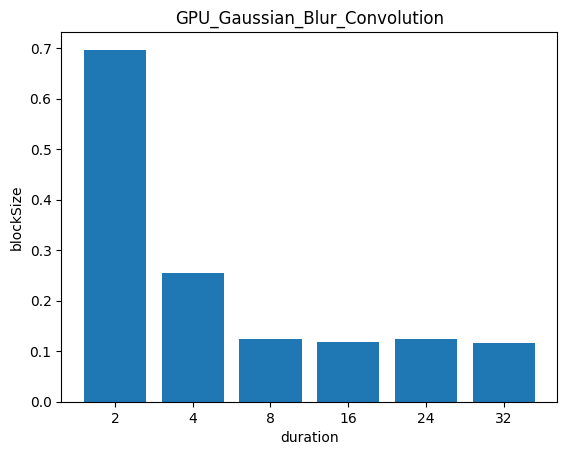

In [30]:
benchmark = [0.697, 0.255, 0.125, 0.119, 0.125, 0.116]
blockSizes = ["2", "4", "8", "16", "24", "32"]
pyplot.title("GPU_Gaussian_Blur_Convolution")
pyplot.xlabel("duration")
pyplot.ylabel("blockSize")
pyplot.bar(blockSizes, benchmark)
pyplot.show()